# Flood AutoML — Balikpapan & Samarinda
**Notebook tunggal, self-contained — seluruh pipeline penelitian ada di sini.**

Memprediksi **potensi kejadian banjir dalam 1-3 hari ke depan** (`Flood_next_3d`) dari data **cuaca + banjir**
yang ditransformasi jadi **time series** (lag `t-1..t-7` + akumulasi/rolling). Bila data
**DEM + RBI** tersedia, pipeline yang sama dipakai untuk membangun **peta probabilitas** banjir.

Sifat penelitian (untuk sidang): **data time series**, **target klasifikasi biner** banjir (0/1)
→ *Time Series Classification / Flood Forecasting Classification*, bukan forecasting nilai kontinu.

### Urutan sel
0. **Clone repository** — ambil semua kode + dataset dari GitHub (Colab).
1. **Pasang dependensi** — termasuk library geospasial (DEM/RBI).
2. **Import** — semua library di satu tempat.
3. **Upload ZIP DEM + RBI** (opsional) — hanya bila ingin jalur geospasial.
4. **Konfigurasi & deteksi MODE**.
5–14. Pipeline: bangun tabel → eksplorasi → preprocessing → imbalance → model+AutoML →
   evaluasi → output prediksi (kota+kecamatan) → feature importance → (geospasial) peta.

`MODE` otomatis: ada DEM+RBI → `geospatial`, jika tidak → `timeseries`.

## 0. Clone repository (Google Colab)
Mengambil seluruh kode + dataset (`processed/`, `clean/`, dll) dari GitHub sehingga notebook
tidak butuh file pendukung lain. **Ganti `REPO_URL`** dengan URL repo-mu. Data **DEM/RBI** tidak
ikut di repo (terlalu besar) — itu di-upload terpisah pada sel 3.

In [2]:
import os, sys, subprocess

REPO_URL = "https://github.com/Noelsip/flood-bpn-smd.git"

def _in_colab():
    return "google.colab" in sys.modules

if _in_colab():
    repo_dir = REPO_URL.rstrip("/").split("/")[-1].replace(".git", "")
    if not os.path.isdir(repo_dir):
        subprocess.run(["git", "clone", REPO_URL], check=True)
    os.chdir(repo_dir)
    print("Repo di-clone. Direktori kerja:", os.getcwd())
else:
    print("Bukan Colab: memakai file repo lokal (tidak perlu clone).")

Repo di-clone. Direktori kerja: /content/flood-bpn-smd


## 1. Pasang dependensi (otomatis di Colab)
Memasang library inti **dan** geospasial (geopandas/rasterio) agar kedua mode siap.

In [3]:
if _in_colab():
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "numpy", "pandas", "scikit-learn", "xgboost", "catboost",
                    "flaml[automl]", "imbalanced-learn", "matplotlib",
                    "geopandas", "rasterio", "shapely", "pyproj", "scipy"], check=True)
    print("Dependensi (inti + geospasial) terpasang.")
else:
    print("Bukan Colab: pastikan requirements.txt sudah terpasang.")

Dependensi (inti + geospasial) terpasang.


## 2. Import (semua library di satu tempat)
Library inti selalu di-import; library geospasial (DEM/RBI) di-import dengan pengaman
(`HAS_GEO_LIBS`) supaya mode time series tetap jalan walau geopandas/rasterio belum ada.

In [4]:
import io, zipfile, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, confusion_matrix, classification_report,
)
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from flaml import AutoML

warnings.filterwarnings("ignore")

try:
    from imblearn.over_sampling import RandomOverSampler
    HAS_OVERSAMPLE = True
except Exception:
    HAS_OVERSAMPLE = False

for _k in ("PROJ_LIB", "PROJ_DATA", "GDAL_DATA"):
    os.environ.pop(_k, None)
try:
    import pyproj
    os.environ["PROJ_LIB"] = pyproj.datadir.get_data_dir()
    import geopandas as gpd
    import rasterio
    from rasterio.transform import rowcol
    from rasterio.warp import calculate_default_transform, reproject, Resampling
    from rasterio.features import rasterize
    from rasterio.mask import mask as rio_mask
    from scipy.ndimage import distance_transform_edt
    from shapely.geometry import Point, box
    HAS_GEO_LIBS = True
except Exception as _e:
    HAS_GEO_LIBS = False
    print("Library geospasial belum ada (mode geospatial nonaktif):", _e)

SEED = 42
np.random.seed(SEED)
print("Import OK | oversampling:", HAS_OVERSAMPLE, "| geospasial:", HAS_GEO_LIBS)

Import OK | oversampling: True | geospasial: True


## 3. Upload ZIP DEM + RBI (opsional, satu ZIP gabungan)
Hanya untuk **jalur geospasial**. Cukup **satu file ZIP** yang menggabungkan DEM dan RBI sekaligus,
dengan struktur folder dipertahankan:
```
dem/DEM SRTM 30M KALIMANTAN TIMUR.tif
RBI/KotaBalikpapan/RBI50K_KOTA BALIKPAPAN_KUGI50.gdb/...
RBI/KotaSamarinda/RBI50K_KOTA SAMARINDA_KUGI50.gdb/...
padat-penduduk/
```
Jika nama file/folder berbeda, sesuaikan `DEM_PATH` / `CITIES` di **Sel 4**.
Lewati sel ini bila hanya menjalankan mode time series (cuaca + banjir).

In [5]:
def upload_dem_rbi():
    if not _in_colab():
        print("Bukan Colab: lewati upload (pakai file lokal bila ada).")
        return
    from google.colab import files
    uploaded = files.upload()  # pilih ZIP DEM+RBI
    for fname, content in uploaded.items():
        if fname.lower().endswith(".zip"):
            with zipfile.ZipFile(io.BytesIO(content)) as z:
                z.extractall(".")
            print("Diekstrak:", fname)
        else:
            Path(fname).write_bytes(content)
            print("Disimpan :", fname)

# Hapus komentar untuk upload ZIP DEM+RBI:
# upload_dem_rbi()
print("Lewati bila mode time series. Hapus komentar upload_dem_rbi() untuk jalur geospasial.")

Lewati bila mode time series. Hapus komentar upload_dem_rbi() untuk jalur geospasial.


## 4. Konfigurasi & deteksi MODE

In [6]:
def find_root(start: Path) -> Path:
    for c in [start, *start.parents]:
        if (c / "processed").exists() or (c / "clean").exists() or (c / "dem").exists():
            return c
    return start

BASE_DIR = find_root(Path.cwd())
OUT_DIR = BASE_DIR / "outputs"; OUT_DIR.mkdir(parents=True, exist_ok=True)

HORIZON, LAGS = 3, 7
TARGET_COL = "Flood_next_3d"
SEED = 42
TIME_BUDGET = 120
UTM_CRS, WGS84 = "EPSG:32750", "EPSG:4326"
DEM_PATH = BASE_DIR / "dem" / "DEM SRTM 30M KALIMANTAN TIMUR.tif"
CLEAN_DIR = BASE_DIR / "clean"; ADMIN_DIR = CLEAN_DIR / "admin"
CITIES = {
    "Balikpapan": dict(
        gdb=BASE_DIR / "RBI" / "KotaBalikpapan" / "RBI50K_KOTA BALIKPAPAN_KUGI50.gdb",
        banjir=CLEAN_DIR / "banjir_balikpapan.csv", penduduk=CLEAN_DIR / "penduduk_balikpapan.csv",
        admin_kec=ADMIN_DIR / "balikpapan_kecamatan.geojson", admin_kel=ADMIN_DIR / "balikpapan_kelurahan.geojson"),
    "Samarinda": dict(
        gdb=BASE_DIR / "RBI" / "KotaSamarinda" / "RBI50K_KOTA SAMARINDA_KUGI50.gdb",
        banjir=CLEAN_DIR / "banjir_samarinda.csv", penduduk=CLEAN_DIR / "penduduk_samarinda.csv",
        admin_kec=ADMIN_DIR / "samarinda_kecamatan.geojson", admin_kel=ADMIN_DIR / "samarinda_kelurahan.geojson"),
}
ADMIN_KEC_NAMECOL, ADMIN_KEL_NAMECOL = "WADMKC", "WADMKD"
L_RIVER, L_ROAD, L_LANDCOVER, LC_CLASS_COL = "SUNGAI_LN_50K", "JALAN_LN_50K", "PENUTUPLAHAN_AR_50K", "REMARK"
POINTS_PER_EVENT, FLOOD_ELEV_QUANTILE, NONFLOOD_ELEV_QUANTILE, NONFLOOD_MIN_DIST = 8, 0.40, 0.50, 750.0
GEO_NUM = ["elevation", "slope", "dist_river", "dist_road", "pop_density"]

POOL_EXTERNAL       = True
REBUILD_CENTRAL_DATASET = True
UNDERSAMPLE_RATIO   = 0
TEST_FRAC           = 0.20
MIN_TEST_SIZE       = 200
PREFLOOD_NEG_RATIO  = 2
EASY_NEG_PERCENTILE = 50
NEGATIVE_LOOKBACK_DAYS = 21
MAX_ALERT_RATE      = 0.06
MIN_RECALL          = 0.05
THRESHOLD_BETA      = 2.0
KALTIM_WEIGHT       = 5.0
USE_OVERSAMPLE      = True
ALERT_COOLDOWN_DAYS = 7
MAX_KECAMATAN_PER_ALERT = 3
ANOMALY_CONTAMINATION = 0.06
KALTIM_CITY_NAMES   = ["Kota Balikpapan", "Kota Samarinda"]
DATASET_DIR         = BASE_DIR / "dataset"
EXTERNAL_FLOOD_DATECOL = "Tanggal / Waktu Kejadian"
EXTERNAL_CITIES = {
    "Bandung":  dict(weather=DATASET_DIR / "cuaca bandung 16-26.csv",  flood=BASE_DIR / "banjir" / "bandung-210 banjir.csv"),
    "Bekasi":   dict(weather=DATASET_DIR / "cuaca bekasi 16-26.csv",   flood=BASE_DIR / "banjir" / "bekasi-134 banjir.csv"),
    "Bogor":    dict(weather=DATASET_DIR / "cuaca bogor 16-26.csv",    flood=BASE_DIR / "banjir" / "bogor-352 banjir.csv"),
    "Pasuruan": dict(weather=DATASET_DIR / "cuaca pasuruan 16-26.csv", flood=BASE_DIR / "banjir" / "pasuruan - 154 banjir.csv"),
}

def geo_missing_files():
    missing = []
    if not HAS_GEO_LIBS:
        missing.append("library geospasial (geopandas/rasterio/pyproj/scipy)")
    if not DEM_PATH.exists():
        missing.append(str(DEM_PATH.relative_to(BASE_DIR) if DEM_PATH.is_relative_to(BASE_DIR) else DEM_PATH))
    for city, cfg in CITIES.items():
        for key in ("gdb", "admin_kec", "admin_kel", "banjir", "penduduk"):
            p = Path(cfg[key])
            if not p.exists():
                label = p.relative_to(BASE_DIR) if p.is_relative_to(BASE_DIR) else p
                missing.append(f"{city}:{key} -> {label}")
    return missing

def geo_ready():
    return len(geo_missing_files()) == 0

GEO_MISSING = geo_missing_files()
MODE = "geospatial" if not GEO_MISSING else "timeseries"
print("Root proyek:", BASE_DIR)
print("MODE:", MODE, "| oversampling:", HAS_OVERSAMPLE, "| geospasial:", HAS_GEO_LIBS)
if GEO_MISSING:
    print("MODE geospatial nonaktif. File/library yang belum ada:")
    for item in GEO_MISSING:
        print(" -", item)
print("POOL_EXTERNAL:", POOL_EXTERNAL, "| kota luar:", list(EXTERNAL_CITIES))

Root proyek: /content/flood-bpn-smd
MODE: timeseries | oversampling: True | geospasial: True
MODE geospatial nonaktif. File/library yang belum ada:
 - dem/DEM SRTM 30M KALIMANTAN TIMUR.tif
 - Balikpapan:gdb -> RBI/KotaBalikpapan/RBI50K_KOTA BALIKPAPAN_KUGI50.gdb
 - Samarinda:gdb -> RBI/KotaSamarinda/RBI50K_KOTA SAMARINDA_KUGI50.gdb
POOL_EXTERNAL: True | kota luar: ['Bandung', 'Bekasi', 'Bogor', 'Pasuruan']


## 5. Fungsi pembangun tabel model
Dua sumber, satu keluaran seragam `(data, info)` sehingga pipeline setelahnya identik.

**A. Time series (dengan DATA POOLING multi-kota)** — transformasi cuaca harian jadi lag `t-1..t-7`
+ akumulasi (hujan 3/7/14 hari, dst) + **anomali persentil-ekspansi per-kota** dan target `Flood_next_3d`.
Dibangun dari `dataset_utama.csv` (Kaltim) yang **digabung** dengan data banjir+cuaca kota luar
(Bandung/Bekasi/Bogor/Pasuruan) **hanya untuk memperkaya pelatihan** (lihat `plan1.md`).
`city` **tidak** dipakai sebagai fitur (location-agnostic); evaluasi & output tetap khusus
Balikpapan & Samarinda.

In [7]:
BASE_DIR = globals().get("BASE_DIR", Path.cwd())
OUT_DIR = globals().get("OUT_DIR", BASE_DIR / "outputs"); OUT_DIR.mkdir(parents=True, exist_ok=True)
HORIZON = globals().get("HORIZON", 3)
LAGS = globals().get("LAGS", 7)
TARGET_COL = globals().get("TARGET_COL", "Flood_next_3d")
SEED = globals().get("SEED", 42)
POOL_EXTERNAL = globals().get("POOL_EXTERNAL", True)
REBUILD_CENTRAL_DATASET = globals().get("REBUILD_CENTRAL_DATASET", False)
UNDERSAMPLE_RATIO = globals().get("UNDERSAMPLE_RATIO", 5)
PREFLOOD_NEG_RATIO = globals().get("PREFLOOD_NEG_RATIO", 2)
EASY_NEG_PERCENTILE = globals().get("EASY_NEG_PERCENTILE", 50)
NEGATIVE_LOOKBACK_DAYS = globals().get("NEGATIVE_LOOKBACK_DAYS", 21)
ALERT_COOLDOWN_DAYS = globals().get("ALERT_COOLDOWN_DAYS", 7)
MAX_KECAMATAN_PER_ALERT = globals().get("MAX_KECAMATAN_PER_ALERT", 3)
ANOMALY_CONTAMINATION = globals().get("ANOMALY_CONTAMINATION", 0.06)
TEST_FRAC = globals().get("TEST_FRAC", 0.20)
MIN_TEST_SIZE = globals().get("MIN_TEST_SIZE", 200)
KALTIM_CITY_NAMES = globals().get("KALTIM_CITY_NAMES", ["Kota Balikpapan", "Kota Samarinda"])
DATASET_DIR = globals().get("DATASET_DIR", BASE_DIR / "dataset")
EXTERNAL_FLOOD_DATECOL = globals().get("EXTERNAL_FLOOD_DATECOL", "Tanggal / Waktu Kejadian")
EXTERNAL_CITIES = globals().get("EXTERNAL_CITIES", {
    "Bandung":  dict(weather=DATASET_DIR / "cuaca bandung 16-26.csv",  flood=BASE_DIR / "banjir" / "bandung-210 banjir.csv"),
    "Bekasi":   dict(weather=DATASET_DIR / "cuaca bekasi 16-26.csv",   flood=BASE_DIR / "banjir" / "bekasi-134 banjir.csv"),
    "Bogor":    dict(weather=DATASET_DIR / "cuaca bogor 16-26.csv",    flood=BASE_DIR / "banjir" / "bogor-352 banjir.csv"),
    "Pasuruan": dict(weather=DATASET_DIR / "cuaca pasuruan 16-26.csv", flood=BASE_DIR / "banjir" / "pasuruan - 154 banjir.csv"),
})

WEATHER_COLS = {
    "precipitation_sum (mm)": "precip",
    "temperature_2m_max (?C)": "tmax",
    "temperature_2m_min (?C)": "tmin",
    "wind_speed_10m_max (km/h)": "wind",
    "rain_sum (mm)": "rain",
    "soil_moisture_0_to_100cm_mean (m?/m?)": "soil",
    "soil_moisture_0_to_100cm_mean (m?/m?)": "soil",
}
SHORT = ["precip", "tmax", "tmin", "wind", "rain", "soil"]
LAG_COLS  = [f"{c}_lag{k}" for c in SHORT for k in range(1, LAGS + 1)]
ROLL_COLS = ["rain_roll3_sum", "rain_roll7_sum", "rain_roll14_sum",
             "precip_roll3_sum", "precip_roll7_sum",
             "soil_roll3_mean", "soil_roll7_mean", "tmax_roll7_mean"]
PCTL_COLS = ["rain7_pctl", "precip7_pctl", "soil7_pctl"]
CALENDAR_COLS = ["doy_sin", "doy_cos", "month_sin", "month_cos"]
TS_FEATURES = LAG_COLS + ROLL_COLS + PCTL_COLS + CALENDAR_COLS
CENTRAL_DATASET_PATH = BASE_DIR / "processed" / "dataset_timeseries.csv"


def _standardize_weather_cols(df):
    rename = {}
    for col in df.columns:
        low = str(col).strip().lower()
        if low.startswith("precipitation_sum"):
            rename[col] = "precip"
        elif low.startswith("temperature_2m_max"):
            rename[col] = "tmax"
        elif low.startswith("temperature_2m_min"):
            rename[col] = "tmin"
        elif low.startswith("wind_speed_10m_max"):
            rename[col] = "wind"
        elif low.startswith("rain_sum"):
            rename[col] = "rain"
        elif low.startswith("soil_moisture_0_to_100cm_mean"):
            rename[col] = "soil"
    return df.rename(columns=rename)


def _load_daily_kaltim(prim_path):
    df = pd.read_csv(prim_path)
    df["time"] = pd.to_datetime(df["time"], errors="coerce").dt.normalize()
    df = _standardize_weather_cols(df)
    return df[["city", "time", *SHORT, "Flood"]].copy()


def _load_daily_external(name, cfg):
    wpath, fpath = Path(cfg["weather"]), Path(cfg["flood"])
    if not wpath.exists() or not fpath.exists():
        print(f"  [SKIP] {name}: file tidak ditemukan ({wpath.name} / {fpath.name})")
        return None
    with open(wpath, encoding="utf-8") as f:
        lines = f.readlines()
    try:
        hdr = next(i for i, line in enumerate(lines) if line.lstrip().startswith("time,"))
    except StopIteration:
        print(f"  [SKIP] {name}: header 'time,' tidak ditemukan di {wpath.name}")
        return None
    w = _standardize_weather_cols(pd.read_csv(wpath, skiprows=hdr))
    missing = [c for c in SHORT if c not in w.columns]
    if missing:
        print(f"  [SKIP] {name}: kolom cuaca hilang {missing}")
        return None
    w["time"] = pd.to_datetime(w["time"], errors="coerce").dt.normalize()
    w = w.dropna(subset=["time"]).sort_values("time")
    full = pd.date_range(w["time"].min(), w["time"].max(), freq="D")
    w = w.set_index("time").reindex(full)[SHORT].rename_axis("time").reset_index()

    fl = pd.read_csv(fpath)
    if "date" in fl.columns:
        fdates = pd.to_datetime(fl["date"], errors="coerce").dt.normalize()
        flood_set = set(fdates.dropna())
    elif {"start_date", "end_date"}.issubset(fl.columns):
        flood_set = set()
        starts = pd.to_datetime(fl["start_date"], errors="coerce").dt.normalize()
        ends = pd.to_datetime(fl["end_date"], errors="coerce").dt.normalize()
        for start, end in zip(starts, ends):
            if pd.notna(start) and pd.notna(end) and end >= start:
                flood_set.update(pd.date_range(start, end, freq="D"))
    elif EXTERNAL_FLOOD_DATECOL in fl.columns:
        fdates = pd.to_datetime(fl[EXTERNAL_FLOOD_DATECOL], errors="coerce").dt.normalize()
        flood_set = set(fdates.dropna())
    else:
        print(f"  [SKIP] {name}: kolom tanggal banjir tidak ditemukan")
        return None
    w["Flood"] = w["time"].isin(flood_set).astype(int)
    w["city"] = name
    return w[["city", "time", *SHORT, "Flood"]]


def _make_ts_features(daily):
    df = daily.sort_values(["city", "time"]).reset_index(drop=True)
    g = df.groupby("city", sort=False)
    day_of_year = df["time"].dt.dayofyear.astype(float)
    month = df["time"].dt.month.astype(float)
    df["doy_sin"] = np.sin(2 * np.pi * day_of_year / 366.0)
    df["doy_cos"] = np.cos(2 * np.pi * day_of_year / 366.0)
    df["month_sin"] = np.sin(2 * np.pi * month / 12.0)
    df["month_cos"] = np.cos(2 * np.pi * month / 12.0)
    for col in SHORT:
        for k in range(1, LAGS + 1):
            df[f"{col}_lag{k}"] = g[col].shift(k)

    def roll(col, w, how):
        shifted = g[col].shift(1)
        per_city = shifted.groupby(df["city"], sort=False)
        if how == "sum":
            return per_city.transform(lambda s: s.rolling(w, min_periods=w).sum())
        return per_city.transform(lambda s: s.rolling(w, min_periods=w).mean())

    df["rain_roll3_sum"], df["rain_roll7_sum"], df["rain_roll14_sum"] = roll("rain", 3, "sum"), roll("rain", 7, "sum"), roll("rain", 14, "sum")
    df["precip_roll3_sum"], df["precip_roll7_sum"] = roll("precip", 3, "sum"), roll("precip", 7, "sum")
    df["soil_roll3_mean"], df["soil_roll7_mean"], df["tmax_roll7_mean"] = roll("soil", 3, "mean"), roll("soil", 7, "mean"), roll("tmax", 7, "mean")

    def exp_pctl(s):
        return s.expanding(min_periods=10).rank(pct=True)
    df["rain7_pctl"]   = df.groupby("city")["rain_roll7_sum"].transform(exp_pctl)
    df["precip7_pctl"] = df.groupby("city")["precip_roll7_sum"].transform(exp_pctl)
    df["soil7_pctl"]   = df.groupby("city")["soil_roll7_mean"].transform(exp_pctl)

    future = [g["Flood"].shift(-step) for step in range(1, HORIZON + 1)]
    df[TARGET_COL] = pd.concat(future, axis=1).max(axis=1)
    df = df.dropna(subset=TS_FEATURES + [TARGET_COL]).reset_index(drop=True)
    df[TARGET_COL] = df[TARGET_COL].astype(int)
    return df


def _select_train_rows_for_balance(train_df, target):
    rng = np.random.RandomState(SEED)
    y = train_df[target].astype(int).to_numpy()
    pos_idx = np.where(y == 1)[0]
    neg_idx = np.where(y == 0)[0]
    if not bool(UNDERSAMPLE_RATIO) or len(pos_idx) == 0:
        return np.arange(len(train_df)), dict(enabled=False, pos=len(pos_idx), neg=len(neg_idx))

    target_neg = int(UNDERSAMPLE_RATIO * len(pos_idx))
    target_preflood = min(int(PREFLOOD_NEG_RATIO * len(pos_idx)), target_neg)
    preflood_mask = np.zeros(len(train_df), dtype=bool)
    for _, grp in train_df.groupby("city", sort=False):
        pos_times = pd.to_datetime(grp.loc[grp[target] == 1, "time"])
        city_idx = grp.index.to_numpy()
        city_times = pd.to_datetime(grp["time"])
        city_preflood = np.zeros(len(grp), dtype=bool)
        for t in pos_times:
            start = t - pd.Timedelta(days=NEGATIVE_LOOKBACK_DAYS)
            city_preflood |= ((city_times >= start) & (city_times < t)).to_numpy()
        preflood_mask[city_idx] = city_preflood

    preflood_neg = neg_idx[preflood_mask[neg_idx]]
    hard_mask = train_df["rain7_pctl"].to_numpy() >= (EASY_NEG_PERCENTILE / 100.0) if "rain7_pctl" in train_df.columns else np.zeros(len(train_df), dtype=bool)
    hard_neg = np.setdiff1d(neg_idx[hard_mask[neg_idx]], preflood_neg, assume_unique=False)
    easy_neg = np.setdiff1d(neg_idx[~hard_mask[neg_idx]], preflood_neg, assume_unique=False)

    selected = []
    if len(preflood_neg):
        selected.extend(rng.choice(preflood_neg, size=min(target_preflood, len(preflood_neg)), replace=False).tolist())
    need = target_neg - len(selected)
    if need > 0 and len(hard_neg):
        selected.extend(rng.choice(hard_neg, size=min(need, len(hard_neg)), replace=False).tolist())
    need = target_neg - len(selected)
    if need > 0 and len(easy_neg):
        selected.extend(rng.choice(easy_neg, size=min(need, len(easy_neg)), replace=False).tolist())

    keep_neg = np.array(selected, dtype=int)
    keep = np.concatenate([pos_idx, keep_neg])
    rng.shuffle(keep)
    stats = dict(enabled=True, pos=len(pos_idx), neg_before=len(neg_idx), neg_after=len(keep_neg),
                 preflood=int(np.isin(keep_neg, preflood_neg).sum()),
                 hard=int(np.isin(keep_neg, hard_neg).sum()),
                 easy=int(np.isin(keep_neg, easy_neg).sum()), ratio=UNDERSAMPLE_RATIO, preflood_ratio=PREFLOOD_NEG_RATIO,
                 lookback_days=NEGATIVE_LOOKBACK_DAYS)
    return keep, stats


def _timeseries_info(target, balance_stats=None):
    return dict(mode="timeseries", target=target, num_cols=TS_FEATURES, cat_cols=[],
                id_cols=["time", "city", "split"], split="role", role_col="split",
                time_col="time", automl_metric="ap",
                kaltim_only_test=None, prebalanced_train=False,
                train_balance_stats=(balance_stats or {}), central_dataset=str(CENTRAL_DATASET_PATH))


def build_timeseries_table():
    TARGET = TARGET_COL
    if CENTRAL_DATASET_PATH.exists() and not REBUILD_CENTRAL_DATASET:
        df = pd.read_csv(CENTRAL_DATASET_PATH)
        df["time"] = pd.to_datetime(df["time"], errors="coerce")
        required = {"city", "time", "split", TARGET, *TS_FEATURES}
        missing = sorted(required - set(df.columns))
        if missing:
            raise ValueError(f"Dataset pusat tidak lengkap: {missing[:10]}")
        print(f"[LOAD] dataset pusat: {CENTRAL_DATASET_PATH} ({len(df)} baris)")
        print(df.groupby(["split", "city"])[TARGET].agg(["count", "sum"]).to_string())
        y_train_loaded = df.loc[df["split"] == "train", TARGET].astype(int)
        balance_stats = dict(enabled=True, pos=int((y_train_loaded == 1).sum()),
                             neg_after=int((y_train_loaded == 0).sum()), ratio=UNDERSAMPLE_RATIO,
                             lookback_days=NEGATIVE_LOOKBACK_DAYS)
        return df, _timeseries_info(TARGET, balance_stats)

    prim = BASE_DIR / "processed" / "dataset_utama.csv"
    if not prim.exists():
        raise FileNotFoundError("processed/dataset_utama.csv tidak ada. Jalankan build_primary_dataset.py / clone repo penuh.")

    daily = _load_daily_kaltim(prim)
    n_ext = 0
    if POOL_EXTERNAL:
        print("Pooling kota luar (training pool):")
        ext_frames = []
        for name, cfg in EXTERNAL_CITIES.items():
            d = _load_daily_external(name, cfg)
            if d is not None:
                ext_frames.append(d); n_ext += 1
                print(f"  [OK]  {name:9s}: {len(d):5d} hari | banjir {int(d['Flood'].sum()):4d} | {d['time'].min().date()} -> {d['time'].max().date()}")
        if ext_frames:
            daily = pd.concat([daily, *ext_frames], ignore_index=True)
    daily = daily.sort_values(["city", "time"]).reset_index(drop=True)

    ts_full = _make_ts_features(daily).sort_values(["time", "city"]).reset_index(drop=True)
    # Test hanya Balikpapan + Samarinda: 20% banjir Kaltim + 20% tidak-banjir Kaltim (tetap urut waktu).
    # Kota luar (pooling) seluruhnya masuk training. Latih = 80% Kaltim per kelas + kota luar.
    is_kaltim = ts_full["city"].isin(KALTIM_CITY_NAMES)
    kaltim = ts_full[is_kaltim]
    external = ts_full[~is_kaltim]
    n_kaltim = len(kaltim)
    n_test_total = min(max(int(round(n_kaltim * TEST_FRAC)), MIN_TEST_SIZE), n_kaltim - 1)
    test_frac_eff = n_test_total / n_kaltim
    train_parts, test_parts = [], []
    for _, grp in kaltim.groupby(TARGET, sort=False):
        grp = grp.sort_values("time")
        n_test = min(max(int(round(len(grp) * test_frac_eff)), 1), len(grp) - 1)
        train_parts.append(grp.iloc[:-n_test])
        test_parts.append(grp.iloc[-n_test:])
    if len(external):
        train_parts.append(external)
    train_df = pd.concat(train_parts).sort_values(["time", "city"]).reset_index(drop=True)
    test_df = pd.concat(test_parts).sort_values(["time", "city"]).reset_index(drop=True)
    train_df["split"] = "train"
    test_df["split"] = "test"
    df = pd.concat([train_df, test_df], ignore_index=True).sort_values(["split", "time", "city"]).reset_index(drop=True)
    balance_stats = dict(test_frac=round(test_frac_eff, 4), n_test=len(test_df), test_cities=KALTIM_CITY_NAMES,
                         train_pos=int((train_df[TARGET] == 1).sum()), train_neg=int((train_df[TARGET] == 0).sum()),
                         test_pos=int((test_df[TARGET] == 1).sum()), test_neg=int((test_df[TARGET] == 0).sum()),
                         oversample_train=True)

    PROC_DIR = BASE_DIR / "processed"; PROC_DIR.mkdir(parents=True, exist_ok=True)
    df.to_csv(CENTRAL_DATASET_PATH, index=False)
    print(f"[SAVE] dataset pusat siap train/test: {CENTRAL_DATASET_PATH}  ({len(df)} baris)")
    print("Balance train:", balance_stats)

    summ = (df.assign(_p=df[TARGET]).groupby(["split", "city"]).agg(n=("_p", "size"), banjir=("_p", "sum")))
    summ["pct"] = (summ["banjir"] / summ["n"] * 100).round(2)
    print(f"\nSumber: dataset_utama.csv (Kaltim) + {n_ext} kota luar | total baris pusat: {len(df)}")
    print(summ.to_string())

    return df, _timeseries_info(TARGET, balance_stats)
print("Fungsi time series siap.")


Fungsi time series siap.


**B. Geospasial (DEM + RBI)** — bangun titik *terrain-constrained* (banjir di zona elevasi rendah
per kecamatan terdampak) + 6 conditioning factor. Library geospasial diimpor di sini agar mode
time series tidak membutuhkannya.

In [8]:
CITY_LAYERS, LC_MAP = {}, {}

def build_geospatial_table():
    global CITY_LAYERS, LC_MAP
    # library geospasial sudah di-import di sel 2 (gpd, rasterio, rowcol, rasterize, dll).
    def _norm(s): return str(s).strip().lower()
    def read_gdb(gdb, layer):
        g = gpd.read_file(gdb, layer=layer); return (g.set_crs(WGS84) if g.crs is None else g).to_crs(UTM_CRS)
    def load_admin(path, col):
        g = gpd.read_file(path)
        if col not in g.columns:
            raise KeyError(f"Kolom {col!r} tidak ada di {Path(path).name}. Kolom: {list(g.columns)}")
        g = (g.set_crs(WGS84) if g.crs is None else g).to_crs(UTM_CRS).copy(); g["adm_name"] = g[col]; return g
    def clip_dem(boundary_wgs, pad=0.02):
        minx, miny, maxx, maxy = boundary_wgs.bounds; bb = box(minx-pad, miny-pad, maxx+pad, maxy+pad)
        with rasterio.open(DEM_PATH) as src:
            arr, tr = rio_mask(src, [bb], crop=True)
            t2, w2, h2 = calculate_default_transform(src.crs, UTM_CRS, arr.shape[2], arr.shape[1],
                *rasterio.transform.array_bounds(arr.shape[1], arr.shape[2], tr))
            dst = np.full((h2, w2), np.nan, dtype="float32")
            reproject(arr[0], dst, src_transform=tr, src_crs=src.crs, dst_transform=t2, dst_crs=UTM_CRS,
                      resampling=Resampling.bilinear, src_nodata=src.nodata, dst_nodata=np.nan)
        return dst.astype(float), t2
    def slope_deg(dem, tr):
        dzdy, dzdx = np.gradient(dem, abs(tr.e), abs(tr.a)); return np.degrees(np.arctan(np.sqrt(dzdx**2 + dzdy**2)))
    def sample_at(points, arr, tr):
        out = []
        for geom in points.geometry:
            r, c = rowcol(tr, geom.x, geom.y)
            out.append(arr[r, c] if (0 <= r < arr.shape[0] and 0 <= c < arr.shape[1]) else np.nan)
        return np.array(out, dtype=float)
    def attach_poly(points, poly, col):
        j = gpd.sjoin(points, poly[["geometry", col]], how="left", predicate="within")
        return j[~j.index.duplicated(keep="first")].loc[points.index, col].values
    def flood_pts_in_kec(poly, n, dem, tr, q, rng):
        H, W = dem.shape
        m = rasterize([(poly, 1)], out_shape=(H, W), transform=tr, fill=0, all_touched=True).astype(bool)
        cells = m & np.isfinite(dem)
        if cells.sum() == 0: return []
        thr = np.nanquantile(dem[cells], q); low = cells & (dem <= thr)
        rows, cols = np.where(low if low.sum() >= n else cells)
        if len(rows) == 0: return []
        idx = rng.choice(len(rows), size=min(n, len(rows)), replace=len(rows) < n)
        return [Point(*rasterio.transform.xy(tr, rows[k], cols[k])) for k in idx]
    def nonflood_pts(flood_gdf, dem, tr, n, q, min_dist, rng):
        minx, miny, maxx, maxy = flood_gdf.total_bounds; pad = 0.15 * max(maxx-minx, maxy-miny)
        minx, miny, maxx, maxy = minx-pad, miny-pad, maxx+pad, maxy+pad
        thr = np.nanquantile(dem, q); uni = flood_gdf.unary_union; pts, t = [], 0
        while len(pts) < n and t < n*400:
            t += 1; px, py = rng.uniform(minx, maxx), rng.uniform(miny, maxy); r, c = rowcol(tr, px, py)
            if not (0 <= r < dem.shape[0] and 0 <= c < dem.shape[1]): continue
            if not np.isfinite(dem[r, c]) or dem[r, c] < thr: continue
            p = Point(px, py)
            if p.distance(uni) < min_dist: continue
            pts.append(p)
        return gpd.GeoDataFrame(geometry=pts, crs=UTM_CRS)

    dfs = {}
    for name, cfg in CITIES.items():
        print("==", name, "=="); rng = np.random.default_rng(SEED)
        kec = load_admin(cfg["admin_kec"], ADMIN_KEC_NAMECOL); desakel = load_admin(cfg["admin_kel"], ADMIN_KEL_NAMECOL)
        bnd = kec.dissolve().geometry.iloc[0]; bnd_wgs = gpd.GeoSeries([bnd], crs=UTM_CRS).to_crs(WGS84).iloc[0]
        dem, tr = clip_dem(bnd_wgs); slope = slope_deg(dem, tr)
        rivers = read_gdb(cfg["gdb"], L_RIVER); rivers = rivers[rivers.intersects(bnd)]
        roads = read_gdb(cfg["gdb"], L_ROAD); roads = roads[roads.intersects(bnd)]
        landcover = read_gdb(cfg["gdb"], L_LANDCOVER); landcover = landcover[landcover.intersects(bnd)]
        pen = pd.read_csv(cfg["penduduk"]); pen["_k"] = pen["kelurahan"].map(_norm)
        desakel["_k"] = desakel["adm_name"].map(_norm); desakel["area_km2"] = desakel.geometry.area / 1e6
        desakel = desakel.merge(pen[["_k", "value", "value_type"]].drop_duplicates("_k"), on="_k", how="left")
        desakel["pop_density"] = np.where(desakel["value_type"].eq("count"), desakel["value"]/desakel["area_km2"], desakel["value"])
        kec["_k"] = kec["adm_name"].map(_norm); bj = pd.read_csv(cfg["banjir"]); bj["_k"] = bj["kecamatan"].map(_norm)
        kec = kec.merge(bj[["_k", "banjir_count"]], on="_k", how="left")
        fpts = []
        for _, row in kec.iterrows():
            cnt = row["banjir_count"]
            if pd.isna(cnt) or cnt <= 0: continue
            fpts += flood_pts_in_kec(row.geometry, int(round(cnt))*POINTS_PER_EVENT, dem, tr, FLOOD_ELEV_QUANTILE, rng)
        fg = gpd.GeoDataFrame(geometry=fpts, crs=UTM_CRS)
        ng = nonflood_pts(fg, dem, tr, len(fg), NONFLOOD_ELEV_QUANTILE, NONFLOOD_MIN_DIST, rng)
        fg["label"], ng["label"] = 1, 0
        pts = gpd.GeoDataFrame(pd.concat([fg[["geometry", "label"]], ng[["geometry", "label"]]], ignore_index=True), geometry="geometry", crs=UTM_CRS)
        ru, rdu = rivers.unary_union, roads.unary_union
        pts["elevation"], pts["slope"] = sample_at(pts, dem, tr), sample_at(pts, slope, tr)
        pts["dist_river"] = pts.geometry.apply(lambda g: g.distance(ru))
        pts["dist_road"] = pts.geometry.apply(lambda g: g.distance(rdu))
        pts["landcover_raw"] = [str(v) for v in attach_poly(pts, landcover, LC_CLASS_COL)]
        pts["pop_density"] = attach_poly(pts, desakel, "pop_density"); pts["city"] = name
        out = pd.DataFrame(pts.drop(columns="geometry")); out["x"], out["y"] = pts.geometry.x.values, pts.geometry.y.values
        dfs[name] = out
        CITY_LAYERS[name] = dict(dem=dem, slope=slope, transform=tr, rivers=rivers, roads=roads, landcover=landcover, desakel=desakel, kec=kec)
    df = pd.concat(dfs.values(), ignore_index=True)
    classes = sorted(df["landcover_raw"].dropna().unique().tolist()); LC_MAP = {c: i for i, c in enumerate(classes)}
    df["landcover"] = df["landcover_raw"].map(LC_MAP).fillna(-1).astype(int)
    info = dict(mode="geospatial", target="label", num_cols=GEO_NUM, cat_cols=["landcover"],
               id_cols=[c for c in ["city", "x", "y"] if c in df.columns],
               split="stratified", time_col=None, automl_metric="roc_auc")
    return df, info
print("Fungsi geospasial siap.")

Fungsi geospasial siap.


## 6. Jalankan proses (satu sel) — bangun tabel model
Memilih sumber otomatis sesuai `MODE`, lalu menghasilkan `data` + `info`. Pipeline di bawahnya identik.

In [9]:
if MODE == "timeseries":
    data, info = build_timeseries_table()
else:
    data, info = build_geospatial_table()

TARGET = info["target"]
data = data.replace([np.inf, -np.inf], np.nan).dropna(subset=info["num_cols"] + info["cat_cols"] + [TARGET]).reset_index(drop=True)
print(f"\nMODE={info['mode']} | tabel model: {data.shape} | target: {TARGET} | split: {info['split']}")
print(f"Fitur: {len(info['num_cols'])} numerik + {len(info['cat_cols'])} kategori")
pos = int(data[TARGET].sum())
print(f"Positif (banjir): {pos}/{len(data)} ({pos/len(data)*100:.2f}%)")
display(data.head(3))

Pooling kota luar (training pool):
  [OK]  Bandung  :  3805 hari | banjir  179 | 2016-01-01 -> 2026-06-01
  [OK]  Bekasi   :  3805 hari | banjir  120 | 2016-01-01 -> 2026-06-01
  [OK]  Bogor    :  3805 hari | banjir  261 | 2016-01-01 -> 2026-06-01
  [OK]  Pasuruan :  3805 hari | banjir  135 | 2016-01-01 -> 2026-06-01
[SAVE] dataset pusat siap train/test: /content/flood-bpn-smd/processed/dataset_timeseries.csv  (21570 baris)
Balance train: {'test_frac': 0.2001, 'n_test': 1284, 'test_cities': ['Kota Balikpapan', 'Kota Samarinda'], 'train_pos': 1909, 'train_neg': 18377, 'test_pos': 30, 'test_neg': 1254, 'oversample_train': True}

Sumber: dataset_utama.csv (Kaltim) + 4 kota luar | total baris pusat: 21570
                          n  banjir    pct
split city                                
test  Kota Balikpapan   643       3   0.47
      Kota Samarinda    641      27   4.21
train Bandung          3788     466  12.30
      Bekasi           3788     306   8.08
      Bogor            3788    

,city,time,precip,tmax,tmin,wind,rain,soil,Flood,doy_sin,...,precip_roll3_sum,precip_roll7_sum,soil_roll3_mean,soil_roll7_mean,tmax_roll7_mean,rain7_pctl,precip7_pctl,soil7_pctl,Flood_next_3d,split
0,Kota Samarinda,2023-08-07,1.6,31.8,23.5,13.7,1.6,0.340,0,-0.579421,...,7.9,10.1,0.352667,0.361000,32.057143,0.022913,0.022913,0.070680,0,test
1,Kota Balikpapan,2023-08-08,0.8,29.3,25.9,20.0,0.8,0.321,0,-0.593327,...,4.5,12.4,0.327667,0.331571,29.357143,0.031444,0.031444,0.016498,0,test
2,Kota Samarinda,2023-08-08,0.8,32.0,23.5,13.0,0.8,0.335,0,-0.593327,...,9.5,11.5,0.346667,0.356000,31.942857,0.026203,0.026203,0.066770,0,test


## 7. Eksplorasi singkat

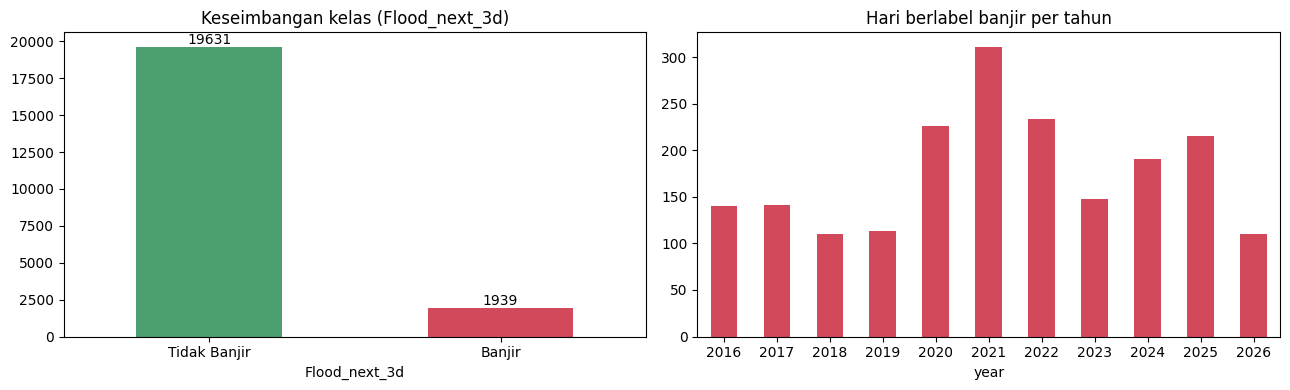

== Banjir historis per kecamatan — Balikpapan (BPS) ==
           kota          kecamatan  banjir_count
Kota Balikpapan Balikpapan Selatan             6
Kota Balikpapan   Balikpapan Timur             4
Kota Balikpapan  Balikpapan Tengah             4
Kota Balikpapan    Balikpapan Kota             2
Kota Balikpapan   Balikpapan Utara             2
Kota Balikpapan   Balikpapan Barat             2
== Banjir historis per kecamatan — Samarinda (BPS) ==
          kota          kecamatan  banjir_count
Kota Samarinda      Samarinda Ulu             8
Kota Samarinda    Samarinda Utara             8
Kota Samarinda     Sungai Kunjang             7
Kota Samarinda            Palaran             5
Kota Samarinda     Samarinda Ilir             5
Kota Samarinda     Loa Janan Ilir             5
Kota Samarinda     Samarinda Kota             4
Kota Samarinda           Sambutan             4
Kota Samarinda      Sungai Pinang             4
Kota Samarinda Samarinda Seberang             3


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
vc = data[TARGET].value_counts().sort_index()
vc.rename({0: "Tidak Banjir", 1: "Banjir"}).plot(kind="bar", ax=ax[0], color=["#4C9F70", "#D1495B"])
ax[0].set_title(f"Keseimbangan kelas ({TARGET})"); ax[0].tick_params(axis="x", rotation=0)
for i, v in enumerate(vc.values):
    ax[0].text(i, v, str(v), ha="center", va="bottom")

if info["time_col"] and info["time_col"] in data.columns:
    data[data[TARGET] == 1].assign(year=data[info["time_col"]].dt.year).groupby("year").size().plot(
        kind="bar", ax=ax[1], color="#D1495B"); ax[1].set_title("Hari berlabel banjir per tahun")
else:
    data.groupby("city")[TARGET].mean().plot(kind="bar", ax=ax[1], color="#D1495B"); ax[1].set_title("Proporsi banjir per kota")
ax[1].tick_params(axis="x", rotation=0); plt.tight_layout(); plt.show()

# Konteks wilayah (dipakai untuk OUTPUT kecamatan di mode time series).
for nm, fn in [("Balikpapan", "clean/banjir_balikpapan.csv"), ("Samarinda", "clean/banjir_samarinda.csv")]:
    p = BASE_DIR / fn
    if p.exists():
        print(f"== Banjir historis per kecamatan — {nm} (BPS) ==")
        print(pd.read_csv(p).sort_values("banjir_count", ascending=False).to_string(index=False))

## 8. Preprocessing & split
Split **berbasis waktu** untuk time series (anti-leakage), **stratified** untuk geospasial.
Scaler & encoder di-fit **hanya pada data latih**.

In [11]:
num_cols, cat_cols = info["num_cols"], info["cat_cols"]
if info["split"] == "role":
    role_col = info.get("role_col", "split")
    train_df = data[data[role_col] == "train"].copy()
    test_df = data[data[role_col] == "test"].copy()
    print("Split dari dataset pusat: train/test")
elif info["split"] == "time":
    ordered = data.sort_values(info["time_col"]).reset_index(drop=True)
    if info.get("cutoff"):
        cutoff = pd.Timestamp(info["cutoff"])
        train_df = ordered[ordered[info["time_col"]] < cutoff].copy()
        test_df  = ordered[ordered[info["time_col"]] >= cutoff].copy()
        print(f"Split waktu @ cutoff {cutoff.date()} (train < cutoff <= test)")
    else:
        cut = int(len(ordered) * 0.70)
        train_df, test_df = ordered.iloc[:cut].copy(), ordered.iloc[cut:].copy()
        print("Split waktu rasio 70/30")
    if info.get("kaltim_only_test") and "city" in test_df.columns:
        before = len(test_df)
        test_df = test_df[test_df["city"].isin(info["kaltim_only_test"])].copy()
        print(f"Test difilter ke Kaltim: {before} -> {len(test_df)} baris (banjir test: {int(test_df[TARGET].sum())})")
else:
    train_df, test_df = train_test_split(data, test_size=0.30, stratify=data[TARGET], random_state=SEED)
train_df = train_df.reset_index(drop=True); test_df = test_df.reset_index(drop=True)
y_train = train_df[TARGET].astype(int).reset_index(drop=True)
y_test = test_df[TARGET].astype(int).reset_index(drop=True)
print("Split:", info["split"], "| Train:", train_df.shape, "| Test:", test_df.shape)
print("Banjir train:", int(y_train.sum()), "| test:", int(y_test.sum()))
print("Kota test:", sorted(test_df["city"].unique().tolist()) if "city" in test_df.columns else "-")


Split dari dataset pusat: train/test
Split: role | Train: (20286, 68) | Test: (1284, 68)
Banjir train: 1909 | test: 30
Kota test: ['Kota Balikpapan', 'Kota Samarinda']


## 9. Penanganan imbalance
Data latih sudah difilter saat dataset pusat dibuat. Semua contoh banjir dipakai, sedangkan contoh tidak banjir diambil secukupnya dari hari pra-banjir dan hari normal. Sel ini menyiapkan scaler, encoder, dan bobot kelas hanya dari data latih.

In [12]:
rng = np.random.RandomState(SEED)
y_tr = y_train.values
pos_idx = np.where(y_tr == 1)[0]
neg_idx = np.where(y_tr == 0)[0]

use_us = (not info.get("prebalanced_train")) and bool(UNDERSAMPLE_RATIO) and len(pos_idx) > 0
if use_us:
    target_neg = int(UNDERSAMPLE_RATIO * len(pos_idx))
    preflood_mask = np.zeros(len(train_df), dtype=bool)
    if {"city", info.get("time_col", "time")}.issubset(train_df.columns):
        time_col = info.get("time_col", "time")
        for city, grp in train_df.groupby("city", sort=False):
            pos_times = pd.to_datetime(grp.loc[grp[TARGET] == 1, time_col])
            city_idx = grp.index.to_numpy()
            city_times = pd.to_datetime(grp[time_col])
            city_preflood = np.zeros(len(grp), dtype=bool)
            for t in pos_times:
                start = t - pd.Timedelta(days=NEGATIVE_LOOKBACK_DAYS)
                city_preflood |= ((city_times >= start) & (city_times < t)).to_numpy()
            preflood_mask[city_idx] = city_preflood

    preflood_neg = neg_idx[preflood_mask[neg_idx]]
    if "rain7_pctl" in train_df.columns:
        hard_mask = train_df["rain7_pctl"].values >= (EASY_NEG_PERCENTILE / 100.0)
        hard_neg = np.setdiff1d(neg_idx[hard_mask[neg_idx]], preflood_neg, assume_unique=False)
        easy_neg = np.setdiff1d(neg_idx[~hard_mask[neg_idx]], preflood_neg, assume_unique=False)
    else:
        hard_neg = np.array([], dtype=int)
        easy_neg = np.setdiff1d(neg_idx, preflood_neg, assume_unique=False)

    selected = []
    if len(preflood_neg):
        selected.extend(rng.choice(preflood_neg, size=min(target_neg, len(preflood_neg)), replace=False).tolist())
    need = target_neg - len(selected)
    if need > 0 and len(hard_neg):
        selected.extend(rng.choice(hard_neg, size=min(need, len(hard_neg)), replace=False).tolist())
    need = target_neg - len(selected)
    if need > 0 and len(easy_neg):
        selected.extend(rng.choice(easy_neg, size=min(need, len(easy_neg)), replace=False).tolist())

    keep_neg = np.array(selected, dtype=int)
    keep = np.concatenate([pos_idx, keep_neg]); rng.shuffle(keep)
    train_fit_df = train_df.iloc[keep].reset_index(drop=True)
    y_fit_base = train_fit_df[TARGET].astype(int).reset_index(drop=True)
    print(f"Undersample TRAIN: neg {len(neg_idx)} -> {len(keep_neg)} | pos {len(pos_idx)} | rasio target 1:{UNDERSAMPLE_RATIO}")
    print(f"  negatif terpilih: pra-banjir={int(np.isin(keep_neg, preflood_neg).sum())}, "
          f"hard={int(np.isin(keep_neg, hard_neg).sum())}, easy={int(np.isin(keep_neg, easy_neg).sum())}")
else:
    train_fit_df = train_df.copy()
    y_fit_base = y_train.copy()
    if info.get("prebalanced_train"):
        print("Undersample: dilewati karena dataset training sudah terfilter/balanced saat build")
        print("Balance train:", info.get("train_balance_stats"))
    else:
        print("Undersample: nonaktif")

scaler = StandardScaler().fit(train_fit_df[num_cols])
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1).fit(train_fit_df[cat_cols]) if cat_cols else None
def transform(frame):
    parts = [pd.DataFrame(scaler.transform(frame[num_cols]), columns=num_cols, index=frame.index)]
    if encoder is not None:
        parts.append(pd.DataFrame(encoder.transform(frame[cat_cols]), columns=cat_cols, index=frame.index))
    return pd.concat(parts, axis=1)

X_train = transform(train_df).reset_index(drop=True)
X_test = transform(test_df).reset_index(drop=True)
X_us = transform(train_fit_df).reset_index(drop=True)
y_us = y_fit_base
# Tandai baris Kaltim supaya bisa diberi bobot lebih besar (model tidak menenggelamkan sinyal Kaltim).
is_kaltim_us = (train_fit_df["city"].isin(KALTIM_CITY_NAMES).astype(int).values
                if "city" in train_fit_df.columns else np.zeros(len(X_us), dtype=int))
X_us = X_us.assign(__kaltim=is_kaltim_us)

neg, pos = int((y_us == 0).sum()), int((y_us == 1).sum())
spw = neg / max(pos, 1)
want_oversample = (USE_OVERSAMPLE or info.get("mode") == "geospatial")
if want_oversample and HAS_OVERSAMPLE and pos > 0 and neg != pos:
    X_fit, y_fit = RandomOverSampler(random_state=SEED).fit_resample(X_us, y_us)
    method, spw_model = "RandomOverSampler", 1.0
else:
    X_fit, y_fit, method, spw_model = X_us, y_us, "class_weight", spw
kaltim_flag = np.asarray(X_fit.pop("__kaltim"))
KALTIM_WEIGHT = globals().get("KALTIM_WEIGHT", 5.0)
sample_weight = np.where(kaltim_flag == 1, KALTIM_WEIGHT, 1.0)
print("Fitur model:", X_fit.shape, "| Test:", X_test.shape)
print(f"Imbalance: {method} | bobot Kaltim: {KALTIM_WEIGHT} (baris Kaltim: {int(kaltim_flag.sum())}) "
      f"| sebaran y_fit: {dict(pd.Series(y_fit).value_counts().sort_index())}")


Undersample: nonaktif
Fitur model: (36754, 57) | Test: (1284, 57)
Imbalance: RandomOverSampler | bobot Kaltim: 5.0 (baris Kaltim: 6213) | sebaran y_fit: {0: np.int64(18377), 1: np.int64(18377)}


## 10. Model baseline, AutoML, dan anomaly detection
Sel ini melatih model supervised seperti biasa, lalu menambah satu baseline anomaly detection. Pendekatannya: pola cuaca normal dipelajari dari baris tidak banjir di data latih; kondisi yang menyimpang diberi skor risiko lebih tinggi.

In [13]:
def fit_all_models(X_fit, y_fit, spw_model, metric, time_budget, sample_weight=None):
    fitted = {}
    fitted["Random Forest"] = RandomForestClassifier(
        n_estimators=400, random_state=SEED, n_jobs=-1, class_weight="balanced_subsample").fit(
        X_fit, y_fit, sample_weight=sample_weight)
    fitted["XGBoost"] = XGBClassifier(
        n_estimators=400, max_depth=4, learning_rate=0.03, subsample=0.85, colsample_bytree=0.85,
        reg_lambda=3.0, reg_alpha=0.5, min_child_weight=3,
        eval_metric="logloss", scale_pos_weight=1.0, random_state=SEED, n_jobs=-1).fit(
        X_fit, y_fit, sample_weight=sample_weight)
    cat_kwargs = dict(iterations=400, depth=6, learning_rate=0.05, random_seed=SEED, verbose=0,
                      allow_writing_files=False)
    if sample_weight is None:
        cat_kwargs["class_weights"] = [1.0, spw_model]
    fitted["CatBoost"] = CatBoostClassifier(**cat_kwargs).fit(X_fit, y_fit, sample_weight=sample_weight)

    normal_rows = X_fit[np.asarray(y_fit).astype(int) == 0]
    anomaly = IsolationForest(n_estimators=400, contamination=ANOMALY_CONTAMINATION, random_state=SEED, n_jobs=-1)
    anomaly.fit(normal_rows)
    fitted["Anomaly Detection"] = anomaly

    automl = AutoML()
    for metric_name, estimators in [(metric, ["rf", "xgboost", "catboost"]),
                                    ("roc_auc", ["rf", "xgboost", "catboost"]),
                                    ("roc_auc", ["rf", "xgboost"] )]:
        try:
            automl.fit(X_train=X_fit, y_train=y_fit, sample_weight=sample_weight, task="classification",
                       metric=metric_name, estimator_list=estimators, time_budget=time_budget,
                       eval_method="cv", n_splits=5, seed=SEED, verbose=1)
            break
        except Exception as e:
            print(f"AutoML retry (metric={metric_name}): {e}")
    fitted["AutoML (FLAML)"] = automl
    return fitted, automl

models, automl = fit_all_models(X_fit, y_fit, spw_model, info["automl_metric"], TIME_BUDGET, sample_weight)
print("Estimator AutoML terbaik:", automl.best_estimator)

Estimator AutoML terbaik: catboost


## 11. Evaluasi dan pemilihan ambang
Semua model dibandingkan pada data test. Ambang operasional dipilih dari data train dengan batas jumlah alert, supaya model tidak terlalu sering memberi peringatan palsu.

Perbandingan model @ threshold 0.5:


,Accuracy,Balanced_Acc,Precision,Recall,F1,AUC_ROC,AUC_PR
Model,,,,,,,
AutoML (FLAML),0.9766,0.5000,0.0000,0.0000,0.0000,0.5233,0.0382
Random Forest,0.9766,0.5000,0.0000,0.0000,0.0000,0.5424,0.0341
CatBoost,0.9688,0.4960,0.0000,0.0000,0.0000,0.4632,0.0337
XGBoost,0.9642,0.5099,0.0556,0.0333,0.0417,0.5076,0.0282
Anomaly Detection,0.9509,0.5031,0.0286,0.0333,0.0308,0.5031,0.0235


model_comparison.csv disimpan: /content/flood-bpn-smd/outputs/timeseries_model_comparison.csv


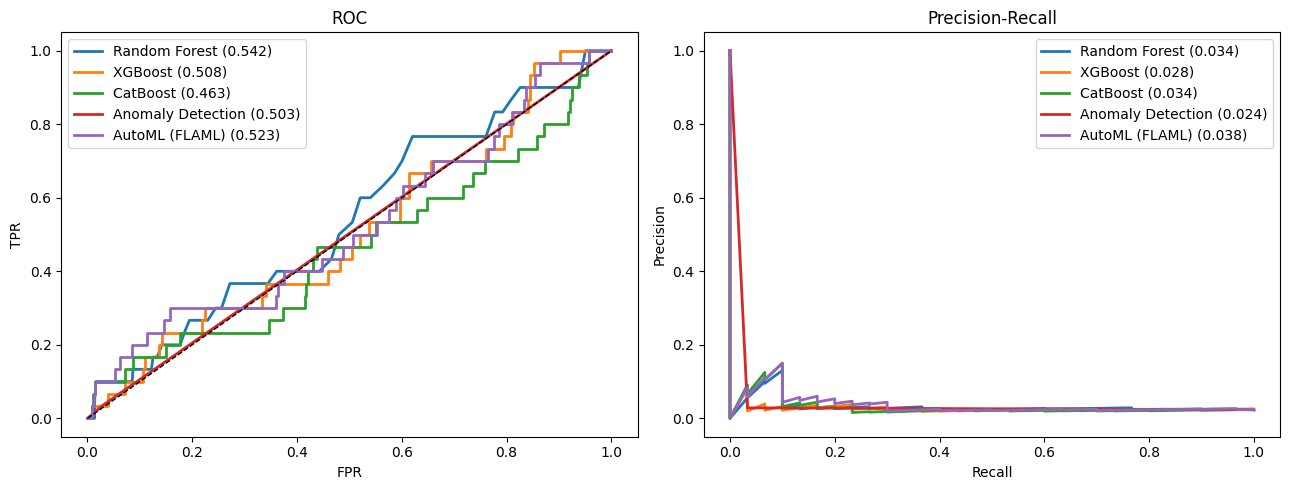

Ambang terbaik per model (F-beta=2.0, utamakan recall, pada data train):


,model,ref,thr,precision,recall,fbeta,alert_rate,n_alert
129,Random Forest,train,0.2900,1.0000,1.0000,1.0000,0.0941,1909
59926,AutoML (FLAML),train,0.8350,0.9995,1.0000,0.9999,0.0942,1910
37082,CatBoost,train,0.5603,0.4299,0.9120,0.7449,0.1996,4050
14968,XGBoost,train,0.5264,0.2867,0.8549,0.6122,0.2806,5692
41210,Anomaly Detection,train,0.0000,0.0941,1.0000,0.3418,1.0000,20286


Model operasional terpilih: Random Forest
Alasan: F-beta=2.0 (utamakan recall) terbaik pada data train
thr               0.29
precision          1.0
recall             1.0
fbeta              1.0
alert_rate    0.094104
n_alert           1909
threshold_train.csv disimpan: /content/flood-bpn-smd/outputs/threshold_train.csv
Evaluasi TEST pada threshold train masing-masing model:


,model,thr,alerts,tp,fp,fn,tn,precision,recall,f1,auc_pr
4,Anomaly Detection,0.0000,1284,30,1254,0,0,0.0234,1.0,0.0457,0.0235
0,Random Forest,0.2900,32,3,29,27,1225,0.0938,0.1,0.0968,0.0341
1,AutoML (FLAML),0.8350,0,0,0,30,1254,0.0000,0.0,0.0000,0.0382
2,CatBoost,0.5603,5,0,5,30,1249,0.0000,0.0,0.0000,0.0337
3,XGBoost,0.5264,10,0,10,30,1244,0.0000,0.0,0.0000,0.0282


Ambang operasional (dari train): 0.2900
Test @0.50           -> Recall=0.000 | Precision=0.000 | Alerts=0
Test @0.290  -> Recall=0.100 | Precision=0.094 | F1=0.097 | Alerts=32


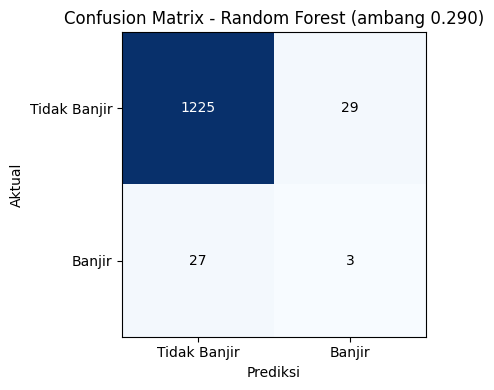

              precision    recall  f1-score   support

Tidak Banjir       0.98      0.98      0.98      1254
      Banjir       0.09      0.10      0.10        30

    accuracy                           0.96      1284
   macro avg       0.54      0.54      0.54      1284
weighted avg       0.96      0.96      0.96      1284



In [14]:
if "models" not in globals():
    needed = [v for v in ["X_fit", "y_fit", "spw_model", "info", "TIME_BUDGET"] if v not in globals()]
    if needed:
        raise RuntimeError(f"Jalankan sel preprocessing dan training dulu. Variabel belum ada: {needed}")
    models, automl = fit_all_models(X_fit, y_fit, spw_model, info["automl_metric"], TIME_BUDGET, globals().get("sample_weight"))

def proba(m, X):
    if isinstance(m, IsolationForest):
        return (m.predict(X) == -1).astype(float)
    return np.asarray(m.predict_proba(X))[:, 1]

rows, results = {}, []
for name, m in models.items():
    p = proba(m, X_test); rows[name] = p; pred = (p >= 0.5).astype(int)
    results.append(dict(Model=name, Accuracy=accuracy_score(y_test, pred),
                        Balanced_Acc=balanced_accuracy_score(y_test, pred),
                        Precision=precision_score(y_test, pred, zero_division=0),
                        Recall=recall_score(y_test, pred, zero_division=0),
                        F1=f1_score(y_test, pred, zero_division=0),
                        AUC_ROC=roc_auc_score(y_test, p) if y_test.nunique() > 1 else np.nan,
                        AUC_PR=average_precision_score(y_test, p) if y_test.nunique() > 1 else np.nan))
res_df = pd.DataFrame(results).set_index("Model").sort_values("AUC_PR", ascending=False)
print("Perbandingan model @ threshold 0.5:"); display(res_df.round(4))
res_df.to_csv(OUT_DIR / f"{info['mode']}_model_comparison.csv")
print("model_comparison.csv disimpan:", OUT_DIR / f"{info['mode']}_model_comparison.csv")

if y_test.nunique() > 1:
    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    for name, p in rows.items():
        fpr, tpr, _ = roc_curve(y_test, p); ax[0].plot(fpr, tpr, lw=2, label=f"{name} ({roc_auc_score(y_test, p):.3f})")
        pr, rc, _ = precision_recall_curve(y_test, p); ax[1].plot(rc, pr, lw=2, label=f"{name} ({average_precision_score(y_test, p):.3f})")
    ax[0].plot([0, 1], [0, 1], "k--", lw=1); ax[0].set_title("ROC"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend()
    ax[1].set_title("Precision-Recall"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].legend()
    plt.tight_layout(); plt.show()


def threshold_candidates(model, model_name):
    p_ref = proba(model, X_train); y_ref = y_train; ref_name = "train"
    thresholds = np.unique(np.r_[np.linspace(0.05, 0.95, 181), p_ref])
    out = []
    beta2 = THRESHOLD_BETA ** 2
    for thr in thresholds:
        pred = (p_ref >= thr).astype(int)
        alert_rate = float(pred.mean())
        precision = precision_score(y_ref, pred, zero_division=0)
        recall = recall_score(y_ref, pred, zero_division=0)
        fbeta = (1 + beta2) * precision * recall / (beta2 * precision + recall + 1e-12)
        out.append(dict(model=model_name, ref=ref_name, thr=float(thr), precision=precision,
                        recall=recall, fbeta=fbeta, alert_rate=alert_rate, n_alert=int(pred.sum())))
    return pd.DataFrame(out)

threshold_table = pd.concat([threshold_candidates(m, name) for name, m in models.items()], ignore_index=True)

model_threshold_rows = []
for model_name, mt in threshold_table.groupby("model", sort=False):
    row = mt.sort_values(["fbeta", "recall", "precision"], ascending=False).iloc[0].copy()
    model_threshold_rows.append(row)
model_threshold_summary = pd.DataFrame(model_threshold_rows).sort_values(
    ["fbeta", "recall", "precision"], ascending=False)
print(f"Ambang terbaik per model (F-beta={THRESHOLD_BETA}, utamakan recall, pada data train):")
display(model_threshold_summary[["model", "ref", "thr", "precision", "recall", "fbeta", "alert_rate", "n_alert"]].round(4))

chosen = model_threshold_summary.iloc[0]
reason = f"F-beta={THRESHOLD_BETA} (utamakan recall) terbaik pada data train"
best_name = str(chosen["model"])
best_model = models[best_name]
OPER_THR = float(chosen["thr"])
threshold_table.to_csv(OUT_DIR / "threshold_train.csv", index=False)
print("Model operasional terpilih:", best_name)
print("Alasan:", reason)
print(chosen[["thr", "precision", "recall", "fbeta", "alert_rate", "n_alert"]].round(4).to_string())
print("threshold_train.csv disimpan:", OUT_DIR / "threshold_train.csv")

test_threshold_rows = []
for _, row in model_threshold_summary.iterrows():
    model_name = str(row["model"])
    thr = float(row["thr"])
    p_model = proba(models[model_name], X_test)
    pred_model = (p_model >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred_model, labels=[0, 1]).ravel()
    test_threshold_rows.append(dict(
        model=model_name, thr=thr, alerts=int(pred_model.sum()), tp=int(tp), fp=int(fp), fn=int(fn), tn=int(tn),
        precision=precision_score(y_test, pred_model, zero_division=0),
        recall=recall_score(y_test, pred_model, zero_division=0),
        f1=f1_score(y_test, pred_model, zero_division=0),
        auc_pr=average_precision_score(y_test, p_model) if y_test.nunique() > 1 else np.nan,
    ))
test_threshold_summary = pd.DataFrame(test_threshold_rows).sort_values(["recall", "f1", "precision"], ascending=False)
print("Evaluasi TEST pada threshold train masing-masing model:")
display(test_threshold_summary.round(4))
test_threshold_summary.to_csv(OUT_DIR / "threshold_test_per_model.csv", index=False)

p_te = proba(best_model, X_test)
print(f"Ambang operasional (dari train): {OPER_THR:.4f}")
print(f"Test @0.50           -> Recall={recall_score(y_test, (p_te >= 0.5).astype(int), zero_division=0):.3f}"
      f" | Precision={precision_score(y_test, (p_te >= 0.5).astype(int), zero_division=0):.3f}"
      f" | Alerts={int((p_te >= 0.5).sum())}")
print(f"Test @{OPER_THR:.3f}  -> Recall={recall_score(y_test, (p_te >= OPER_THR).astype(int), zero_division=0):.3f}"
      f" | Precision={precision_score(y_test, (p_te >= OPER_THR).astype(int), zero_division=0):.3f}"
      f" | F1={f1_score(y_test, (p_te >= OPER_THR).astype(int), zero_division=0):.3f}"
      f" | Alerts={int((p_te >= OPER_THR).sum())}")

best_pred = (p_te >= OPER_THR).astype(int)
cm = confusion_matrix(y_test, best_pred)
fig, axc = plt.subplots(figsize=(4.5, 4)); axc.imshow(cm, cmap="Blues")
axc.set_xticks([0, 1]); axc.set_xticklabels(["Tidak Banjir", "Banjir"]); axc.set_yticks([0, 1]); axc.set_yticklabels(["Tidak Banjir", "Banjir"])
axc.set_xlabel("Prediksi"); axc.set_ylabel("Aktual"); axc.set_title(f"Confusion Matrix - {best_name} (ambang {OPER_THR:.3f})")
for (r, c), v in np.ndenumerate(cm):
    axc.text(c, r, str(v), ha="center", va="center", color="white" if v > cm.max()/2 else "black")
plt.tight_layout(); plt.show()
print(classification_report(y_test, best_pred, target_names=["Tidak Banjir", "Banjir"], zero_division=0))


In [15]:
if info.get("mode") == "timeseries" and POOL_EXTERNAL and "city" in train_df.columns:
    def _prep_ablation(train_raw, y_raw):
        sc = StandardScaler().fit(train_raw[num_cols])
        Xtr = pd.DataFrame(sc.transform(train_raw[num_cols]), columns=num_cols, index=train_raw.index).reset_index(drop=True)
        Xte = pd.DataFrame(sc.transform(test_df[num_cols]), columns=num_cols, index=test_df.index).reset_index(drop=True)
        return Xtr, y_raw.reset_index(drop=True), Xte

    def _fit_ablation_model(model_name, Xtr, ytr):
        spw_ = int((ytr == 0).sum()) / max(int((ytr == 1).sum()), 1)
        if model_name == "Random Forest":
            return RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1,
                                          class_weight="balanced_subsample").fit(Xtr, ytr)
        if model_name == "XGBoost":
            return XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.03, subsample=0.85,
                                 colsample_bytree=0.85, reg_lambda=3.0, reg_alpha=0.5,
                                 min_child_weight=3, eval_metric="logloss", scale_pos_weight=1.0,
                                 random_state=SEED, n_jobs=-1).fit(Xtr, ytr)
        return CatBoostClassifier(iterations=300, depth=6, learning_rate=0.05, random_seed=SEED,
                                  verbose=0, allow_writing_files=False,
                                  class_weights=[1.0, spw_]).fit(Xtr, ytr)

    def _eval_ablation(model_name, train_raw, y_raw):
        Xtr, ytr, Xte = _prep_ablation(train_raw, y_raw)
        model = _fit_ablation_model(model_name, Xtr, ytr)
        p_tr = proba(model, Xtr)
        p_te = proba(model, Xte)
        if ytr.nunique() > 1:
            pr, rc, th = precision_recall_curve(ytr, p_tr)
            f1_train = 2 * pr * rc / (pr + rc + 1e-12)
            thr = float(th[int(np.nanargmax(f1_train[:-1]))]) if len(th) else 0.5
        else:
            thr = 0.5
        pred = (p_te >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()
        return dict(recall=recall_score(y_test, pred, zero_division=0),
                    precision=precision_score(y_test, pred, zero_division=0),
                    f1=f1_score(y_test, pred, zero_division=0),
                    pr_auc=average_precision_score(y_test, p_te) if y_test.nunique() > 1 else np.nan,
                    balanced_acc=balanced_accuracy_score(y_test, pred),
                    tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp), thr=round(thr, 4))

    scenarios = {
        "baseline": train_df["city"].isin(KALTIM_CITY_NAMES).values,
        "pooled": np.ones(len(train_df), dtype=bool),
    }
    rows = []
    for scenario, mask in scenarios.items():
        tr_raw = train_df.loc[mask].reset_index(drop=True)
        y_raw = tr_raw[TARGET].astype(int)
        for model_name in ["Random Forest", "XGBoost", "CatBoost"]:
            rows.append(dict(scenario=scenario, model=model_name, n_train=int(len(tr_raw)),
                             n_flood_train=int(y_raw.sum()),
                             **_eval_ablation(model_name, tr_raw, y_raw)))

    abl_df = pd.DataFrame(rows)
    print(f"ABLATION - evaluasi pada TEST Kaltim: {int(y_test.sum())} event banjir dari {len(y_test)} hari")
    display(abl_df.round(4))
    abl_df.to_csv(OUT_DIR / "ablation_results.csv", index=False)

    pivot_recall = abl_df.pivot(index="model", columns="scenario", values="recall")
    if {"baseline", "pooled"}.issubset(pivot_recall.columns):
        print("\nDelta recall pooled-baseline per model:")
        display((pivot_recall["pooled"] - pivot_recall["baseline"]).rename("delta_recall").round(4))
    print("Tersimpan:", OUT_DIR / "ablation_results.csv")
else:
    print("Ablation dilewati (hanya untuk mode timeseries + POOL_EXTERNAL).")


ABLATION - evaluasi pada TEST Kaltim: 30 event banjir dari 1284 hari


,scenario,model,n_train,n_flood_train,recall,precision,f1,pr_auc,balanced_acc,tn,fp,fn,tp,thr
0,baseline,Random Forest,5134,122,0.0000,0.0000,0.0000,0.0415,0.5000,1254,0,30,0,0.5667
1,baseline,XGBoost,5134,122,0.0333,0.1429,0.0541,0.0840,0.5143,1248,6,29,1,0.1355
2,baseline,CatBoost,5134,122,0.0000,0.0000,0.0000,0.0498,0.5000,1254,0,30,0,0.9404
3,pooled,Random Forest,20286,1909,0.0000,0.0000,0.0000,0.0323,0.5000,1254,0,30,0,0.5800
4,pooled,XGBoost,20286,1909,0.0000,0.0000,0.0000,0.0270,0.4996,1253,1,30,0,0.2149
5,pooled,CatBoost,20286,1909,0.0000,0.0000,0.0000,0.0295,0.4960,1244,10,30,0,0.6686



Delta recall pooled-baseline per model:


,delta_recall
model,
CatBoost,0.0000
Random Forest,0.0000
XGBoost,-0.0333


Tersimpan: /content/flood-bpn-smd/outputs/ablation_results.csv


## 12. Output prediksi kota dan kecamatan
Model time series hanya memprediksi tanggal-kota. Karena cuaca tidak punya koordinat kecamatan, kecamatan ditambahkan sebagai prior dari riwayat BPS. Output dibatasi ke beberapa kecamatan teratas supaya hasil tidak terlihat seperti semua kecamatan selalu terkena.

In [16]:
if MODE == "timeseries":
    THR = OPER_THR if "OPER_THR" in dir() else 0.5
    cooldown_days = globals().get("ALERT_COOLDOWN_DAYS", 7)
    max_kec = globals().get("MAX_KECAMATAN_PER_ALERT", 3)
    id_cols = [c for c in info["id_cols"] if c in test_df.columns]
    pred_df = test_df[id_cols].copy()
    pred_df["flood_proba"] = proba(best_model, X_test)
    pred_df["flood_pred_raw"] = (pred_df["flood_proba"] >= THR).astype(int)
    pred_df["flood_actual"] = y_test.values

    raw_hot = pred_df[pred_df["flood_pred_raw"] == 1].copy()
    selected_idx = []
    for city, grp in raw_hot.sort_values("flood_proba", ascending=False).groupby("city", sort=False):
        kept_times = []
        for idx, row in grp.iterrows():
            t = pd.Timestamp(row["time"])
            if all(abs((t - kt).days) >= cooldown_days for kt in kept_times):
                selected_idx.append(idx)
                kept_times.append(t)
    pred_df["flood_pred"] = 0
    pred_df.loc[selected_idx, "flood_pred"] = 1
    pred_df.to_csv(OUT_DIR / "timeseries_predictions_kota.csv", index=False)

    hot = pred_df[pred_df["flood_pred"] == 1].sort_values(["time", "city"]).copy()
    if hot.empty:
        hot = pred_df.sort_values("flood_proba", ascending=False).groupby("city", as_index=False).head(5)
        print("Tidak ada prediksi >= ambang setelah cooldown; menampilkan top-5 hari paling berisiko per kota.")

    cand, seen, kec_frames = [], set(), []
    for root in [BASE_DIR, Path.cwd(), BASE_DIR.parent]:
        cand += [root / "clean" / "banjir_balikpapan.csv", root / "clean" / "banjir_samarinda.csv"]
    for p in cand:
        rp = Path(p).resolve()
        if rp.exists() and rp not in seen:
            seen.add(rp); kec_frames.append(pd.read_csv(rp))
    if kec_frames:
        kec = pd.concat(kec_frames, ignore_index=True).rename(columns={"kota": "city", "banjir_count": "banjir_historis"})
        kec = kec.sort_values(["city", "banjir_historis"], ascending=[True, False]).groupby("city", as_index=False).head(max_kec)
        out = hot.merge(kec[["city", "kecamatan", "banjir_historis"]], on="city", how="left")
        out = out.sort_values(["time", "city", "banjir_historis"], ascending=[True, True, False]).reset_index(drop=True)
    else:
        out = hot.assign(kecamatan=np.nan, banjir_historis=np.nan)
        print("clean/banjir_*.csv tidak ditemukan -> kecamatan NaN. Pastikan folder clean/ ada (clone repo penuh).")

    cols = [c for c in ["time", "city", "kecamatan", "banjir_historis", "latitude", "longitude",
                        "flood_proba", "flood_pred", "flood_pred_raw", "flood_actual"] if c in out.columns]
    out = out[cols]
    out.to_csv(OUT_DIR / "timeseries_predictions_kecamatan.csv", index=False)
    raw_alerts = int(pred_df["flood_pred_raw"].sum())
    final_alerts = int(pred_df["flood_pred"].sum())
    caught = int(((pred_df["flood_pred"] == 1) & (pred_df["flood_actual"] == 1)).sum())
    print(f"Alert mentah: {raw_alerts} | setelah cooldown {cooldown_days} hari: {final_alerts} | TP: {caught} dari {int(pred_df['flood_actual'].sum())} kejadian aktual")
    print(f"Output kota+kecamatan: {len(out)} baris | max kecamatan per alert: {max_kec}. Contoh:")
    display(out.head(30))
    print("Tersimpan:", OUT_DIR / "timeseries_predictions_kecamatan.csv")
else:
    print("Mode geospatial: output kecamatan/koordinat berupa peta probabilitas (sel 14).")

Alert mentah: 32 | setelah cooldown 7 hari: 6 | TP: 1 dari 30 kejadian aktual
Output kota+kecamatan: 18 baris | max kecamatan per alert: 3. Contoh:


,time,city,kecamatan,banjir_historis,flood_proba,flood_pred,flood_pred_raw,flood_actual
0,2023-11-22,Kota Samarinda,Samarinda Ulu,8,0.3225,1,1,0
1,2023-11-22,Kota Samarinda,Samarinda Utara,8,0.3225,1,1,0
2,2023-11-22,Kota Samarinda,Sungai Kunjang,7,0.3225,1,1,0
3,2024-11-21,Kota Samarinda,Samarinda Ulu,8,0.3950,1,1,0
4,2024-11-21,Kota Samarinda,Samarinda Utara,8,0.3950,1,1,0
5,2024-11-21,Kota Samarinda,Sungai Kunjang,7,0.3950,1,1,0
6,2024-11-23,Kota Balikpapan,Balikpapan Selatan,6,0.4675,1,1,0
7,2024-11-23,Kota Balikpapan,Balikpapan Timur,4,0.4675,1,1,0
8,2024-11-23,Kota Balikpapan,Balikpapan Tengah,4,0.4675,1,1,0
9,2024-11-30,Kota Balikpapan,Balikpapan Selatan,6,0.4175,1,1,0


Tersimpan: /content/flood-bpn-smd/outputs/timeseries_predictions_kecamatan.csv


## 13. Feature importance & simpan hasil

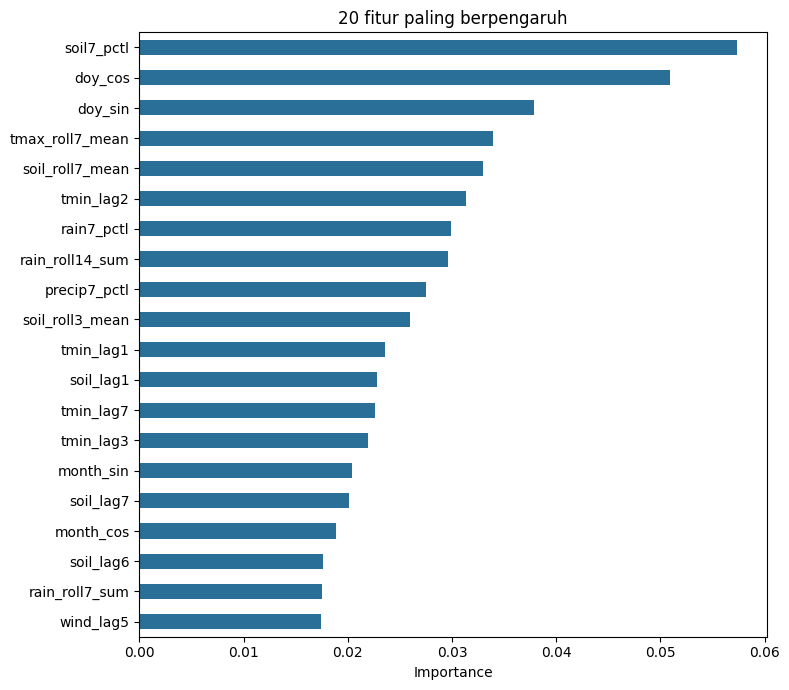

,Random Forest,XGBoost,CatBoost,AutoML (FLAML),mean
soil7_pctl,0.0391,0.0241,0.0915,0.0746,0.0573
doy_cos,0.0316,0.0214,0.0778,0.0728,0.0509
doy_sin,0.0291,0.0179,0.0536,0.0507,0.0378
tmax_roll7_mean,0.0241,0.0212,0.0453,0.0452,0.0339
soil_roll7_mean,0.0274,0.0274,0.0438,0.0333,0.0330
tmin_lag2,0.0256,0.0515,0.0248,0.0234,0.0313
rain7_pctl,0.0299,0.0311,0.0265,0.0320,0.0299
rain_roll14_sum,0.0255,0.0222,0.0318,0.0388,0.0296
precip7_pctl,0.0286,0.0352,0.0325,0.0137,0.0275
soil_roll3_mean,0.0240,0.0340,0.0250,0.0210,0.0260


Tersimpan: /content/flood-bpn-smd/outputs/timeseries_model_comparison.csv


In [17]:
frames = []
for name, m in models.items():
    imp = getattr(m, "feature_importances_", None)
    if imp is None and name == "AutoML (FLAML)":
        est = getattr(getattr(m, "model", None), "estimator", None); imp = getattr(est, "feature_importances_", None)
    if imp is not None and len(imp) == X_train.shape[1]:
        frames.append(pd.Series(np.asarray(imp) / (np.sum(imp) + 1e-12), index=X_train.columns, name=name))
if frames:
    imp_df = pd.concat(frames, axis=1); imp_df["mean"] = imp_df.mean(axis=1)
    imp_df.sort_values("mean").tail(20)["mean"].plot(kind="barh", figsize=(8, 7), color="#2A6F97")
    plt.title("20 fitur paling berpengaruh"); plt.xlabel("Importance"); plt.tight_layout(); plt.show()
    display(imp_df.sort_values("mean", ascending=False).head(15).round(4))

res_df.to_csv(OUT_DIR / f"{info['mode']}_model_comparison.csv")
print("Tersimpan:", OUT_DIR / f"{info['mode']}_model_comparison.csv")

## 14. (Khusus geospasial) Peta probabilitas banjir per kota dan kecamatan
Hanya berjalan bila `MODE == "geospatial"`. Sel ini memprediksi probabilitas tiap sel grid DEM, lalu menyimpan:
- GeoTIFF raster probabilitas per kota.
- PNG raster probabilitas per kota.
- CSV + GeoJSON ringkasan risiko per kecamatan.
- PNG choropleth kecamatan yang menunjukkan wilayah mana yang lebih berisiko.

In [18]:
if MODE == "geospatial":
    def _zonal_stats_by_kecamatan(kec_gdf, pmap, tr, city_name, thr):
        rows = []
        H, W = pmap.shape
        valid_map = np.isfinite(pmap)
        for _, row in kec_gdf.iterrows():
            mask_arr = rasterize([(row.geometry, 1)], out_shape=(H, W), transform=tr, fill=0, all_touched=True).astype(bool)
            vals = pmap[mask_arr & valid_map]
            if len(vals) == 0:
                mean_prob, max_prob, pct_alert = np.nan, np.nan, np.nan
            else:
                mean_prob = float(np.nanmean(vals))
                max_prob = float(np.nanmax(vals))
                pct_alert = float((vals >= thr).mean())
            rows.append({
                "city": city_name,
                "kecamatan": row["adm_name"],
                "banjir_historis": row.get("banjir_count", np.nan),
                "mean_flood_proba": mean_prob,
                "max_flood_proba": max_prob,
                "pct_area_alert": pct_alert,
                "geometry": row.geometry,
            })
        out = gpd.GeoDataFrame(rows, geometry="geometry", crs=kec_gdf.crs)
        out["risk_score"] = (
            out["mean_flood_proba"].fillna(0) * 0.60
            + out["max_flood_proba"].fillna(0) * 0.25
            + out["pct_area_alert"].fillna(0) * 0.15
        )
        out["risk_rank"] = out["risk_score"].rank(method="first", ascending=False).astype(int)
        return out.sort_values("risk_rank")

    geo_outputs = []
    THR = OPER_THR if "OPER_THR" in dir() else 0.5
    for name, lyr in CITY_LAYERS.items():
        dem, slope, tr = lyr["dem"], lyr["slope"], lyr["transform"]
        rivers, roads, landcover, desakel, kec = lyr["rivers"], lyr["roads"], lyr["landcover"], lyr["desakel"], lyr["kec"]
        H, W = dem.shape; px = abs(tr.a)
        rmask = rasterize(((g, 1) for g in rivers.geometry), out_shape=(H, W), transform=tr, fill=0, all_touched=True)
        dmask = rasterize(((g, 1) for g in roads.geometry), out_shape=(H, W), transform=tr, fill=0, all_touched=True)
        grid = pd.DataFrame({
            "elevation": dem.ravel(),
            "slope": slope.ravel(),
            "dist_river": (distance_transform_edt(rmask == 0) * px).ravel(),
            "dist_road": (distance_transform_edt(dmask == 0) * px).ravel(),
            "pop_density": rasterize(
                ((g, float(v)) for g, v in zip(desakel.geometry, desakel["pop_density"]) if pd.notna(v)),
                out_shape=(H, W), transform=tr, fill=np.nan, dtype="float32").ravel(),
            "landcover": rasterize(
                ((g, LC_MAP.get(str(v), -1)) for g, v in zip(landcover.geometry, landcover[LC_CLASS_COL])),
                out_shape=(H, W), transform=tr, fill=-1, dtype="float32").ravel().astype(int),
        })
        valid = grid[num_cols].notna().all(axis=1).values
        prob = np.full(len(grid), np.nan)
        if valid.sum() > 0:
            prob[valid] = proba(best_model, transform(grid.loc[valid]))
        pmap = prob.reshape(H, W)

        tif = OUT_DIR / f"flood_probability_{name}.tif"
        with rasterio.open(tif, "w", driver="GTiff", height=H, width=W, count=1, dtype="float32",
                           crs=UTM_CRS, transform=tr, nodata=np.nan) as dst:
            dst.write(pmap.astype("float32"), 1)

        fig, ax = plt.subplots(figsize=(8, 8))
        im = ax.imshow(pmap, cmap="turbo", vmin=0, vmax=1)
        kec.boundary.plot(ax=ax, color="white", linewidth=0.8)
        plt.colorbar(im, ax=ax, label="Probabilitas banjir")
        ax.set_title(f"Peta Probabilitas - {name} ({best_name})")
        ax.axis("off")
        raster_png = OUT_DIR / f"flood_probability_{name}.png"
        plt.savefig(raster_png, dpi=150, bbox_inches="tight"); plt.show()

        kec_risk = _zonal_stats_by_kecamatan(kec, pmap, tr, name, THR)
        kec_csv = OUT_DIR / f"flood_risk_kecamatan_{name}.csv"
        kec_geojson = OUT_DIR / f"flood_risk_kecamatan_{name}.geojson"
        kec_png = OUT_DIR / f"flood_risk_kecamatan_{name}.png"
        kec_risk.drop(columns="geometry").to_csv(kec_csv, index=False)
        kec_risk.to_crs(WGS84).to_file(kec_geojson, driver="GeoJSON")

        fig, ax = plt.subplots(figsize=(8, 8))
        kec_risk.plot(column="risk_score", ax=ax, cmap="YlOrRd", legend=True,
                      edgecolor="#333333", linewidth=0.7,
                      missing_kwds={"color": "lightgrey", "label": "No data"})
        for _, r in kec_risk.head(8).iterrows():
            rp = r.geometry.representative_point()
            ax.text(rp.x, rp.y, str(r["risk_rank"]), ha="center", va="center", fontsize=8,
                    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.75))
        ax.set_title(f"Risiko Banjir per Kecamatan - {name} ({best_name})")
        ax.axis("off")
        plt.savefig(kec_png, dpi=150, bbox_inches="tight"); plt.show()

        geo_outputs.append(kec_risk.drop(columns="geometry"))
        print("Tersimpan peta raster:", tif, "|", raster_png)
        print("Tersimpan risiko kecamatan:", kec_csv, "|", kec_geojson, "|", kec_png)
        display(kec_risk.drop(columns="geometry").head(10).round(4))

    if geo_outputs:
        all_kec = pd.concat(geo_outputs, ignore_index=True).sort_values(["city", "risk_rank"])
        all_kec.to_csv(OUT_DIR / "flood_risk_kecamatan_all.csv", index=False)
        print("Ringkasan semua kecamatan:", OUT_DIR / "flood_risk_kecamatan_all.csv")
else:
    print("Lewati: peta probabilitas hanya untuk MODE geospatial. Upload/letakkan folder dem/ dan RBI/ agar MODE menjadi geospatial.")

Lewati: peta probabilitas hanya untuk MODE geospatial. Upload/letakkan folder dem/ dan RBI/ agar MODE menjadi geospatial.


---
## Catatan metodologi
- Target utama adalah `Flood_next_3d`: banjir terjadi dalam 1-3 hari ke depan.
- Data kota luar dipakai hanya untuk training, sedangkan test tetap Balikpapan-Samarinda.
- Anomaly detection dipakai sebagai pembanding: pola cuaca tidak banjir dipelajari sebagai kondisi normal, lalu kondisi yang menyimpang diberi skor risiko lebih tinggi.
- Output kecamatan pada mode time series adalah prior lokasi dari riwayat BPS. Peta kecamatan dari DEM/RBI dibuat ketika `MODE=geospatial` aktif.